## **1. Import Libraries**
---

In [1]:
import os
os.makedirs('./resources/dataset' , exist_ok=True)

# Training data (COCO2017 test set - 6GB - 40K images)
!wget http://images.cocodataset.org/zips/test2017.zip -P './resources/dataset'
!unzip -q './resources/dataset/test2017.zip' -d './resources/dataset'
os.remove('./resources/dataset/test2017.zip')

--2025-03-17 11:41:10--  http://images.cocodataset.org/zips/test2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 3.5.0.62, 54.231.199.249, 3.5.25.25, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|3.5.0.62|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6646970404 (6.2G) [application/zip]
Saving to: ‘./resources/dataset/test2017.zip’

test2017.zip        100%[===================>]   6.19G  53.8MB/s    in 2m 0s   

2025-03-17 11:43:11 (52.8 MB/s) - ‘./resources/dataset/test2017.zip’ saved [6646970404/6646970404]



In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision import models, datasets, transforms
from torchvision.utils import save_image

import os
import sys
import glob
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from torch.autograd import Variable
from collections import OrderedDict, namedtuple

In [3]:
def set_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)  # Set seed for Python's hash function
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.benchmark = True     # Optimize performance if input size is fixed
    torch.backends.cudnn.deterministic = True # Ensure reproducibility (may slow down training)

In [4]:
# For reproducibility
set_seed(42)

# Device
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device_cnt = torch.cuda.device_count()
print(f"device: {device}, num device: {device_cnt}")

# Constant
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])  

device: cuda, num device: 1


## **2. Defining Models**
---

In [5]:
class VGG16(torch.nn.Module):
    def __init__(self, requires_grad=False):
        super().__init__()
        
        vgg_pretrained_features = models.vgg16(pretrained=True).features

        self.slice1 = torch.nn.Sequential(OrderedDict([(str(x), vgg_pretrained_features[x]) for x in range(4)]))
        self.slice2 = torch.nn.Sequential(OrderedDict([(str(x), vgg_pretrained_features[x]) for x in range(4, 9)]))
        self.slice3 = torch.nn.Sequential(OrderedDict([(str(x), vgg_pretrained_features[x]) for x in range(9, 16)]))
        self.slice4 = torch.nn.Sequential(OrderedDict([(str(x), vgg_pretrained_features[x]) for x in range(16, 23)]))
            
        if not requires_grad:
            for param in self.parameters():
                param.requires_grad = False

    def forward(self, X):
        features = []
        for slice_layer in [self.slice1, self.slice2, self.slice3, self.slice4]:
            X = slice_layer(X)
            features.append(X)
    
        return namedtuple("VggOutputs", ["relu1_2", "relu2_2", "relu3_3", "relu4_3"])(*features)

In [6]:
class TransformerNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        
        self.model = nn.Sequential(
            ConvBlock(3, 32, kernel_size=9, stride=1),
            ConvBlock(32, 64, kernel_size=3, stride=2),
            ConvBlock(64, 128, kernel_size=3, stride=2),
            ResidualBlock(128),
            ResidualBlock(128),
            ResidualBlock(128),
            ResidualBlock(128),
            ResidualBlock(128),
            ConvBlock(128, 64, kernel_size=3, upsample=True),
            ConvBlock(64, 32, kernel_size=3, upsample=True),
            ConvBlock(32, 3, kernel_size=9, stride=1, normalize=False, relu=False),
        )

    def forward(self, x):
        return self.model(x)


class ResidualBlock(torch.nn.Module):
    def __init__(self, channels):
        super().__init__()
        
        self.block = nn.Sequential(
            ConvBlock(channels, channels, kernel_size=3, stride=1, normalize=True, relu=True),
            ConvBlock(channels, channels, kernel_size=3, stride=1, normalize=True, relu=False),
        )

    def forward(self, x):
        return self.block(x) + x


class ConvBlock(torch.nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, upsample=False, normalize=True, relu=True):
        super(ConvBlock, self).__init__()
        
        self.upsample = upsample
        self.block = nn.Sequential(
            nn.ReflectionPad2d(kernel_size // 2), 
            nn.Conv2d(in_channels, out_channels, kernel_size, stride)
        )
        self.norm = nn.InstanceNorm2d(out_channels, affine=True) if normalize else None
        self.relu = relu

    def forward(self, x):
        if self.upsample:
            x = F.interpolate(x, scale_factor=2)
        x = self.block(x)
        if self.norm is not None:
            x = self.norm(x)
        if self.relu:
            x = F.relu(x)
        return x

## **3. Utility Functions**
---

In [7]:
def gram_matrix(tensor):
    B, C, H, W = tensor.size()
    features   = tensor.view(B, C, H * W)
    gram       = torch.bmm(features, features.transpose(1, 2))
    gram       = gram.div(C * H * W)
    return gram

In [8]:
def train_transform(image_size):
    return transforms.Compose([
        transforms.Resize((int(image_size * 1.15),int(image_size * 1.15))),
        transforms.RandomCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])


def style_transform(image_size=None):
    resize    = [transforms.Resize((image_size,image_size))] if image_size else []
    transform = transforms.Compose(resize + [transforms.ToTensor(), transforms.Normalize(mean, std)])
    return transform


def test_transform(image_size=None):
    resize    = [transforms.Resize(image_size)] if image_size else []
    transform = transforms.Compose(resize + [transforms.ToTensor(), transforms.Normalize(mean, std)])
    return transform

In [ ]:
def denormalize(tensors):
    for c in range(3):
        tensors[:, c].mul_(std[c]).add_(mean[c])
    return tensors


# def deprocess(image_tensor):
#     image_tensor  = denormalize(image_tensor)[0]
#     image_tensor *= 255
#     image_np      = torch.clamp(image_tensor, 0, 255).cpu().numpy().astype(np.uint8)
#     image_np      = image_np.transpose(1, 2, 0)
#     return image_np

## **4. Training**
---

In [10]:
def trainer(style_image, style_name, dataset_path, image_size=256, style_size=448,
            batch_size=8, lr=1e-5, epochs=1, 
            checkpoint_model=None, checkpoint_interval=200, sample_interval=200, 
            style_weight=10e10, content_weight=10e5):

    os.makedirs(f"./training/outputs/{style_name}", exist_ok=True)
    os.makedirs(f"./training/checkpoints", exist_ok=True)

    
    # Define network
    transformer = TransformerNet().to(device)
    vgg         = VGG16(requires_grad=False).to(device)
    
    if checkpoint_model:
        transformer.load_state_dict(torch.load(checkpoint_model))
        
    optimizer = Adam(transformer.parameters(), lr)
    l2_loss   = torch.nn.MSELoss().to(device)

    
    # Preprare data
    train_dataset = datasets.ImageFolder(dataset_path, train_transform(image_size))
    dataloader    = DataLoader(train_dataset, batch_size=batch_size)
    print(f"Train set size : {len(train_dataset)}")
    print(f"Dataloader size: {len(dataloader)}")

    style          = style_transform(style_size)(Image.open(style_image))
    style          = style.repeat(batch_size, 1, 1, 1).to(device)
    features_style = vgg(style)
    gram_style     = [gram_matrix(y) for y in features_style]

    
    # Validate
    image_samples = []
    for path in random.sample(glob.glob(f"{dataset_path}/*/*.jpg"), 8):
        image_samples += [style_transform(image_size)(Image.open(path))]
    image_samples = torch.stack(image_samples)

    def save_sample(batches_done):
        transformer.eval()
        with torch.no_grad():
            output = transformer(image_samples.to(device))
            
        image_grid = denormalize(torch.cat((image_samples.cpu(), output.cpu()), 2))
        save_image(image_grid, f"./training/outputs/{style_name}/{batches_done}.jpg", nrow=4)
        
        transformer.train()
    

    # Training
    train_metrics = {'content': [], 'style': [], 'total': []}
    best_loss     = float('inf')
    
    for epoch in range(epochs):
        epoch_metrics = {'content': [], 'style': [], 'total': []}
        
        for batch_i, (images, _) in enumerate(dataloader):
            optimizer.zero_grad()

            # Extract features
            images_original      = images.to(device)
            images_transformed   = transformer(images_original)
            features_original    = vgg(images_original)
            features_transformed = vgg(images_transformed)

            # Compute loss
            content_loss = content_weight * l2_loss(features_transformed.relu2_2, features_original.relu2_2)
            
            style_loss = 0
            for ft_y, gm_s in zip(features_transformed, gram_style):
                gm_y = gram_matrix(ft_y)
                style_loss += l2_loss(gm_y, gm_s[: images.size(0), :, :])
            style_loss *= style_weight
            
            total_loss = content_loss + style_loss

            # Backpropagation
            total_loss.backward()
            optimizer.step()

            # Log
            for key, loss in zip(['content', 'style', 'total'], [content_loss, style_loss, total_loss]):
                epoch_metrics[key].append(loss.item())
                train_metrics[key].append(loss.item())
                
            sys.stdout.write(
                f"\r[Epoch {epoch + 1}/{epochs}] [Batch {batch_i + 1}/{len(dataloader)}]"
                f"\t[Content loss: {content_loss.item():.2f} (epoch avg: {np.mean(epoch_metrics['content']):.2f}) (avg: {np.mean(train_metrics['content']):.2f})]"
                f"\t[Style loss: {style_loss.item():.2f} (epoch avg: {np.mean(epoch_metrics['style']):.2f}) (avg: {np.mean(train_metrics['style']):.2f})]"
                f"\t[Total loss: {total_loss.item():.2f} (epoch avg: {np.mean(epoch_metrics['total']):.2f}) (avg: {np.mean(train_metrics['total']):.2f})]"
            )

            # Checkpoint
            batches_done = epoch * len(dataloader) + batch_i + 1
            
            if batches_done % sample_interval == 0:
                save_sample(batches_done)

            if checkpoint_interval > 0 and batches_done % checkpoint_interval == 0:
                torch.save(transformer.state_dict(), f"./training/checkpoints/{style_name}_{batches_done}.pth")

            if total_loss.item() < best_loss:
                best_loss = total_loss.item()
                torch.save(transformer.state_dict(), f"./training/checkpoints/best_model.pth")
            
            torch.save(transformer.state_dict(), f"./training/checkpoints/last_checkpoint.pth")
    
    print("\nTraining Completed!")

    
    # Plot loss curve
    plt.plot(train_metrics['content'], label = 'Content Loss')
    plt.plot(train_metrics['style'], label = 'Style Loss')
    plt.plot(train_metrics['total'], label = 'Total Loss')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.legend()
    plt.show()

## **5. Testing & Inference**
---

In [ ]:
# Group 1: Animal x Post Impressionism
CONTENT_IMG = './resources/images/content_1-Animal.png'
STYLE_IMG   = './resources/styles/style_1-Post_Impressionism.png'

CONTENT     = os.path.basename(CONTENT_IMG).split('.')[0].split('-')[1]
STYLE       = os.path.basename(STYLE_IMG).split('.')[0].split('-')[1]

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/checkpoints/vgg16-397923af.pth



Train set size : 40670
Dataloader size: 5084
[Epoch 5/5] [Batch 5084/5084]	[Content loss: 5686376.00 (epoch avg: 5844103.87) (avg: 6747056.54)]	[Style loss: 1569923.50 (epoch avg: 1627821.93) (avg: 2106782.85)]	[Total loss: 7256299.50 (epoch avg: 7471925.80) (avg: 8853839.39)]
Training Completed!


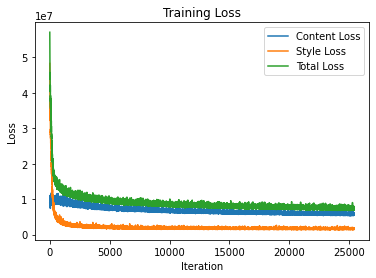

In [12]:
trainer(
    style_image=STYLE_IMG, style_name=STYLE, dataset_path='./resources/dataset',
    image_size=256, style_size=448,
    batch_size=8, lr=1e-5, epochs=5,
    checkpoint_model=None, checkpoint_interval=200, sample_interval=200,
    style_weight=10e10, content_weight=10e5,
)

In [13]:
def test_image(content_image, content_name, style_name, checkpoint_model, save_path):
    os.makedirs(os.path.join(save_path,"results"), exist_ok=True)

    # Load model
    transformer = TransformerNet().to(device)
    transformer.load_state_dict(torch.load(checkpoint_model))
    transformer.eval()
    
    # Inference
    image_tensor = Variable(test_transform()(Image.open(content_image))).to(device)
    image_tensor = image_tensor.unsqueeze(0)
    with torch.no_grad():
        stylized_image = denormalize(transformer(image_tensor)).cpu()

    # Save image
    fn   = checkpoint_model.split('/')[-1].split('.')[0]
    path = os.path.join(save_path,f"results/{fn}-{content_name}-x-{style_name}.png")
    
    save_image(stylized_image, path)
    plt.imshow(cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB))
    print("Image Saved!")

Image Saved!


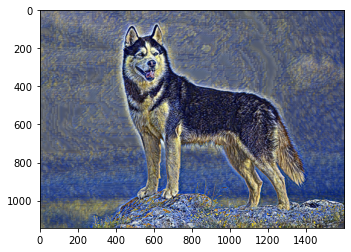

In [14]:
test_image(content_image=CONTENT_IMG,
           content_name=CONTENT,
           style_name=STYLE,
           checkpoint_model='./training/checkpoints/best_model.pth',
           save_path='./')